In [1]:
import sys
import torch 
import os

""" Run this cell before you run anything. This ensures the modular imports work correctly"""

working_root_directory="/teamspace/studios/this_studio/resnet18_cifar10_classifier"

if working_root_directory not in sys.path: 
    sys.path.append(working_root_directory)

In [2]:
from utils.helper_utils import (
    load_prepare_cifar10,
    build_transforms,
    load_resnet18
    )

from utils.visualization_utils import (
    load_and_plot_metrics_history,
    load_csv_main_model_metrics_history,
    extract_dataframe,
    confusion_matrix_plot,
    sample_image,
    each_class_accuracy
    )

from src.test import load_model_for_test,test_model
from config.exp_config import dataset_dir,baseline_model_dir,csv_file_path
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt 

In [3]:
#Device
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cpu


In [4]:
def get_datasets(baseline_model:bool):
        
        flag=True 
        add_erasing=True

        if baseline_model:
                flag=False
                add_erasing=False

        #download cifar10 dataset if it doesn't exist or it is corrupted
        train_dataset,val_dataset,test_dataset=load_prepare_cifar10(
                dataset_path=f"../{dataset_dir}", #notice i have chaged the dataset dir due to current script running jupyter notebook dir
                build_transforms=build_transforms,
                image_size=224,
                standard_aug=flag ,#set False not to be applied standard augmentation or True
                add_random_erasing=add_erasing
                )
        return train_dataset,val_dataset,test_dataset 

In [5]:
def plot_consine_annealing_performance(
    csv_file_dict:dict,
    save_path: str|None=None
    ):

    """
    Plots the learning rates across different layers over epochs.
    
    Parameters:
        csv_file_dict (dict): The dict for csv dict
        save_path (str, optional): File path to save the generated plot.
    """
    plt.figure(figsize=(10, 6))
    
    # Plot each learning rate series
    plt.plot(range(1,csv_file_dict["epoch"]+1),csv_file_dict["fc_lr"], label='FC Layer LR')
    plt.plot(range(1,csv_file_dict["epoch"]+1),csv_file_dict["layer3_lr"], label= 'Layer3 LR')
    plt.plot(range(1,csv_file_dict["epoch"]+1),csv_file_dict["layer4_lr"], label='Layer 4 LR')
    
    # Formatting the plot
    plt.title('Cosine Annealing Performance', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Learning Rate', fontsize=12)
    
    # Use scientific notation for small learning rates
    plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    plt.legend(fontsize=11, loc='upper right')
    plt.tight_layout()
    
    # Save or show the plot
    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"Plot successfully saved to {save_path}")
    else:
        plt.show()



In [6]:
def get_test_history_dict(dict_path:str,experiment_name:str): 
    "load saved history dict"
    history=torch.load(os.path.join(f"{dict_path}/{experiment_name}","test_history.pth"))

    return history

In [7]:
train_dataset,val_dataset,test_dataset=get_datasets(baseline_model=False)

downloaded cifar10 dataset ...


In [8]:
print(f"length of train dataset after splitting {len(train_dataset)}")
print(f"length of val dataset after splitting {len(val_dataset)}")
print(f"length of test dataset  {len(test_dataset)}")

#get the classes
cifar10_classes=train_dataset.subset.dataset.classes
cifar10_classes_len=len(cifar10_classes)
#num classes
print(cifar10_classes)
print(f"Len of classes {cifar10_classes_len}")

length of train dataset after splitting 40000
length of val dataset after splitting 10000
length of test dataset  10000
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Len of classes 10


In [9]:
test_loader = DataLoader(
        test_dataset,
        batch_size=128,
        shuffle=False,          # no need to shuffle test set
        num_workers=4,
        pin_memory=True,        # speeds up transfer to GPU
        persistent_workers=True # keeps workers alive across epochs
    )

In [10]:
#call pretrained resnet18 and freezed backbone model
model=load_resnet18(device=device)
for name,param in model.named_parameters():
  print(f"{name}:{param.requires_grad}")

print(f"classification layer head {model.fc.out_features}")

conv1.weight:False
bn1.weight:False
bn1.bias:False
layer1.0.conv1.weight:False
layer1.0.bn1.weight:False
layer1.0.bn1.bias:False
layer1.0.conv2.weight:False
layer1.0.bn2.weight:False
layer1.0.bn2.bias:False
layer1.1.conv1.weight:False
layer1.1.bn1.weight:False
layer1.1.bn1.bias:False
layer1.1.conv2.weight:False
layer1.1.bn2.weight:False
layer1.1.bn2.bias:False
layer2.0.conv1.weight:False
layer2.0.bn1.weight:False
layer2.0.bn1.bias:False
layer2.0.conv2.weight:False
layer2.0.bn2.weight:False
layer2.0.bn2.bias:False
layer2.0.downsample.0.weight:False
layer2.0.downsample.1.weight:False
layer2.0.downsample.1.bias:False
layer2.1.conv1.weight:False
layer2.1.bn1.weight:False
layer2.1.bn1.bias:False
layer2.1.conv2.weight:False
layer2.1.bn2.weight:False
layer2.1.bn2.bias:False
layer3.0.conv1.weight:False
layer3.0.bn1.weight:False
layer3.0.bn1.bias:False
layer3.0.conv2.weight:False
layer3.0.bn2.weight:False
layer3.0.bn2.bias:False
layer3.0.downsample.0.weight:False
layer3.0.downsample.1.weight:Fa

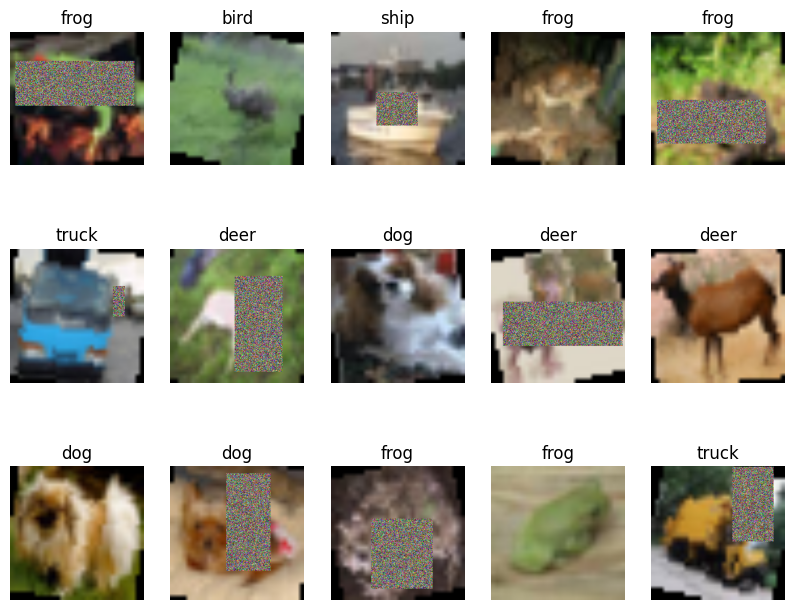

In [11]:
sample_image(train_dataset,test_set=False) #plot unnormalized 15 images

# Baseline Model

## Baseline model plot for train accuracy/loss and val accuracy/loss to optimize the model performance

##### Note: when using "load_and_plot_metrics_history" for plotting the baseline metrics or main model metrics histories, note that baseline=True and baseline_path are only used for plotting baseline history. When setting baseline=True, don't forget to set the baseline_path too.

In [24]:
load_and_plot_metrics_history(
    train_legend_acc_name="Train Accuracy",
    val_legend_acc_name="Val Accuracy",
    train_legend_loss_name="Train Loss",
    val_legend_loss_name="Val Loss",
    epochs=10,
    experiment_name="(only unfreezing fc layer) baseline",
    baseline=True,
    baseline_path=baseline_model_dir
)

baseline - True is only for baseline plots


KeyError: 'train_acc'

# Experiment 2
## CSV file for experiment 2 (baseline + unfreezing layer4 and fc)

In [ ]:
exp2_csv=load_csv_main_model_metrics_history(csv_file_path=csv_file_path,experiment_name="exp2")

csv_files (debugging): ['/teamspace/studios/this_studio/resnet18_cifar10_classifier/results/exp2/metrics_v1.csv', '/teamspace/studios/this_studio/resnet18_cifar10_classifier/results/exp2/metrics_v2.csv']


In [ ]:
#extract and preprare the csv experiment2 dataframe to dictionary for easier plotting 
experiment2_prepared_csv=extract_dataframe(df=exp2_csv)

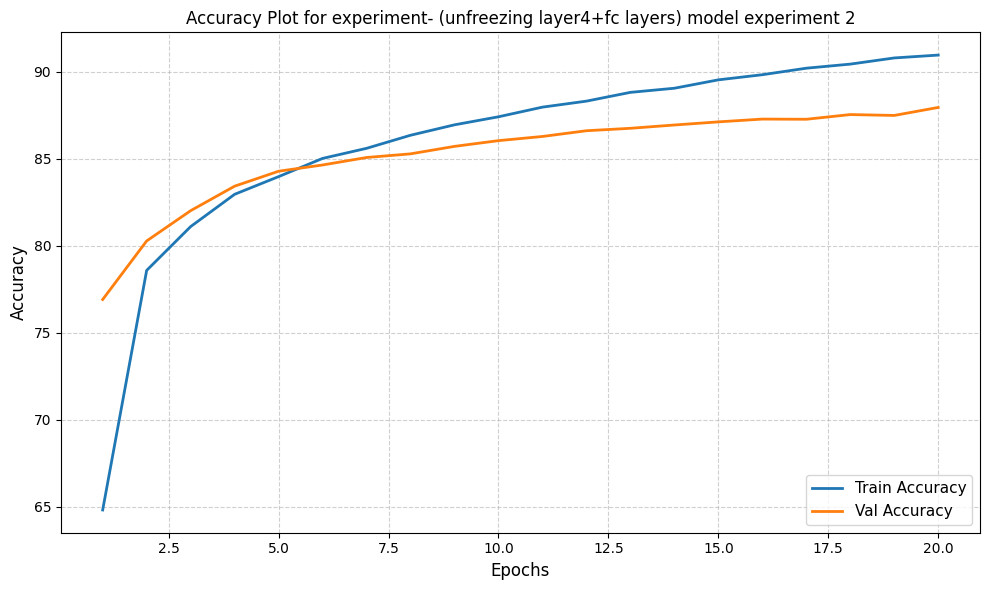

Accuracy plot has been plotted


Train Accuracy for (unfreezing layer4+fc layers) model experiment 2: 90.97
Val Accuracy for (unfreezing layer4+fc layers) model experiment 2: 87.96


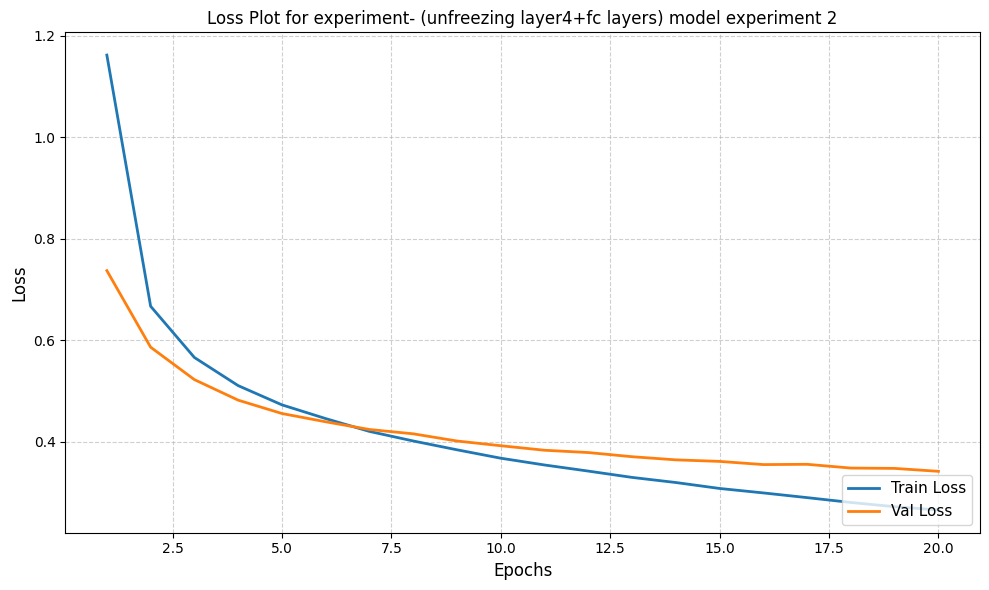

Loss plot has been plotted


Train Loss for (unfreezing layer4+fc layers) model experiment 2: 0.27
Val Loss for (unfreezing layer4+fc layers) model experiment 2: 0.34


In [ ]:
load_and_plot_metrics_history(
    train_legend_acc_name="Train Accuracy",
    val_legend_acc_name="Val Accuracy",
    train_legend_loss_name="Train Loss",
    val_legend_loss_name="Val Loss",
    epochs=experiment2_prepared_csv["epoch"],
    experiment_name="(unfreezing layer4+fc layers) model experiment 2",
    baseline=False,
    main_model_history=experiment2_prepared_csv
)

# Experiment 3 
## (Exp2+standard augmentation (RandomHorizonalFlip(p=0.5)+RandomRotation(degrees=15)))

In [ ]:
exp3_csv=load_csv_main_model_metrics_history(csv_file_path=csv_file_path,experiment_name="exp3")

csv_files (debugging): ['/teamspace/studios/this_studio/resnet18_cifar10_classifier/results/exp3/metrics3_V1.csv', '/teamspace/studios/this_studio/resnet18_cifar10_classifier/results/exp3/metrics3_V2.csv', '/teamspace/studios/this_studio/resnet18_cifar10_classifier/results/exp3/metrics3_V3.csv']


In [ ]:
#extract and preprare the csv experiment3 dataframe to dictionary for easier plotting 
experiment3_prepared_csv=extract_dataframe(df=exp3_csv)

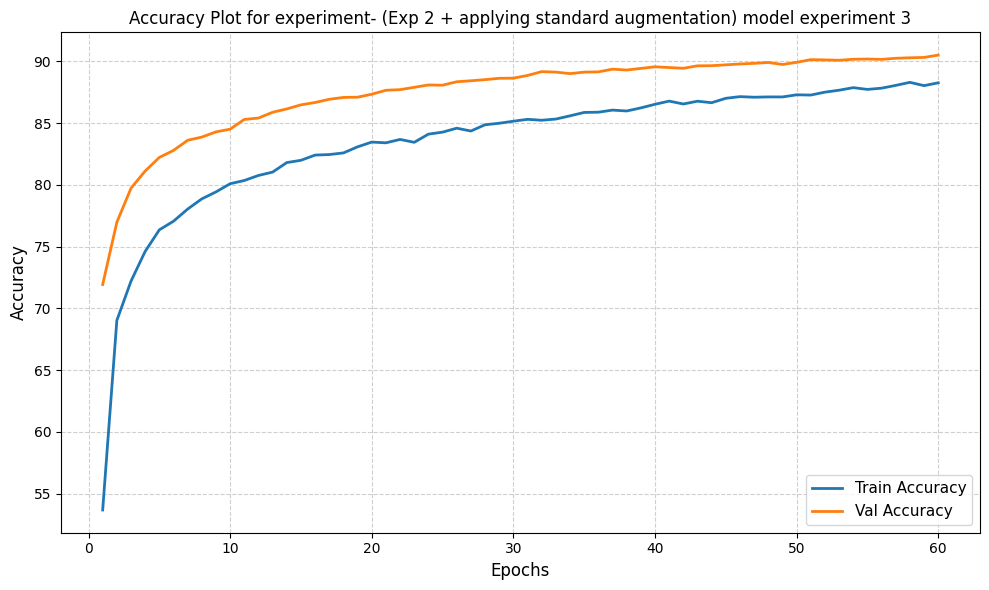

Accuracy plot has been plotted


Train Accuracy for (Exp 2 + applying standard augmentation) model experiment 3: 88.30
Val Accuracy for (Exp 2 + applying standard augmentation) model experiment 3: 90.51


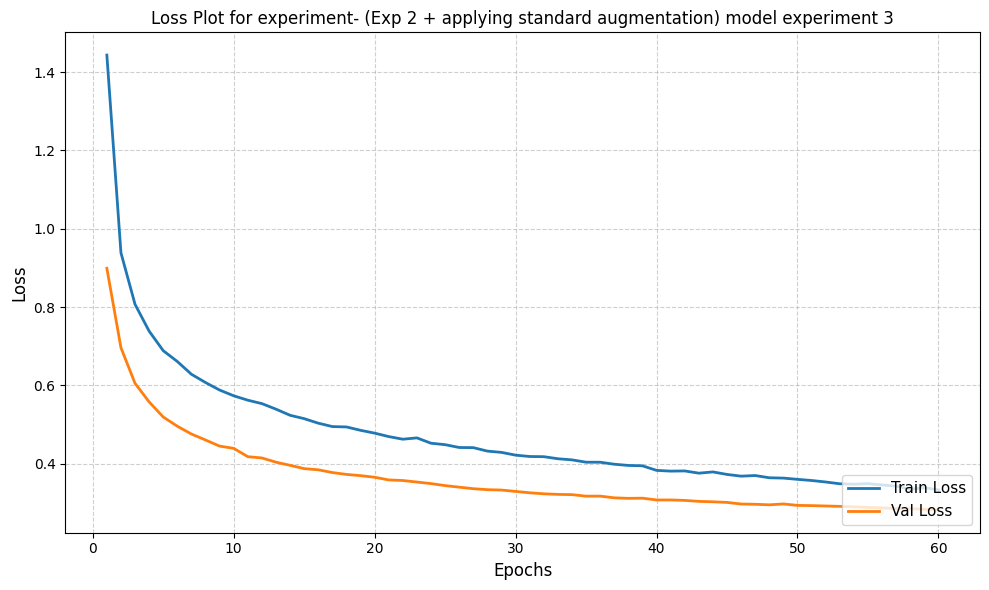

Loss plot has been plotted


Train Loss for (Exp 2 + applying standard augmentation) model experiment 3: 0.33
Val Loss for (Exp 2 + applying standard augmentation) model experiment 3: 0.28


In [ ]:
load_and_plot_metrics_history(
    train_legend_acc_name="Train Accuracy",
    val_legend_acc_name="Val Accuracy",
    train_legend_loss_name="Train Loss",
    val_legend_loss_name="Val Loss",
    epochs=experiment3_prepared_csv["epoch"],
    experiment_name="(Exp 2 + applying standard augmentation) model experiment 3",
    baseline=False,
    main_model_history=experiment3_prepared_csv
)

## Exp5 ----- with standard augmentation (RandomHorizonalFlip(p=0.5)+RandomRotation(degrees=15)) + Consine Annealing + Cutmix and Mixup + unfreezing layer3 (lr=2e-4)+layer4(lr=3e-4)+ fc(lr=3e-3)

In [ ]:
exp5_v2_csv=load_csv_main_model_metrics_history(csv_file_path=csv_file_path,experiment_name="exp5")

csv_files (debugging): ['/teamspace/studios/this_studio/resnet18_cifar10_classifier/results/exp5/metrics_exp5_v2.csv']


In [ ]:
#extract and preprare the csv experiment5 version 2 dataframe to dictionary for easier plotting 
experiment5_v2_prepared_csv=extract_dataframe(df=exp5_v2_csv)

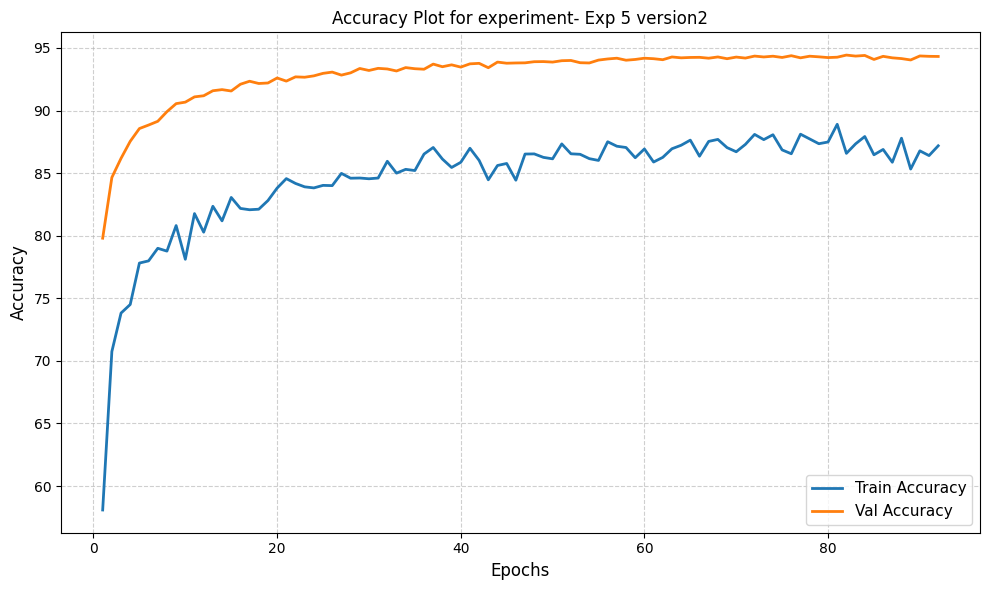

Accuracy plot has been plotted


Train Accuracy for Exp 5 version2: 88.90
Val Accuracy for Exp 5 version2: 94.43


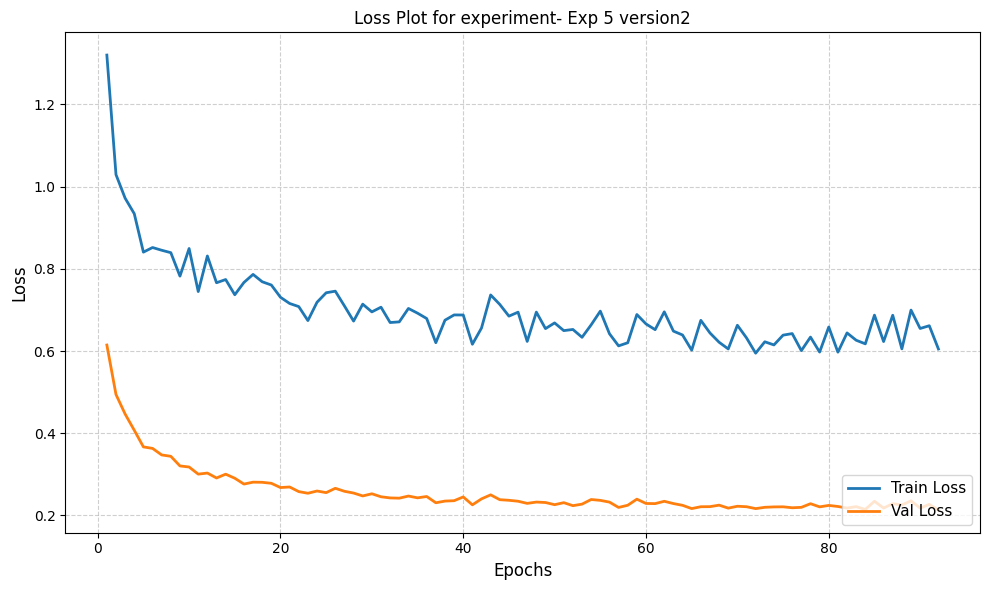

Loss plot has been plotted


Train Loss for Exp 5 version2: 0.59
Val Loss for Exp 5 version2: 0.21


In [ ]:
load_and_plot_metrics_history(
    train_legend_acc_name="Train Accuracy",
    val_legend_acc_name="Val Accuracy",
    train_legend_loss_name="Train Loss",
    val_legend_loss_name="Val Loss",
    epochs=experiment5_v2_prepared_csv["epoch"],
    experiment_name="Exp 5 version2",
    baseline=False,
    main_model_history=experiment5_v2_prepared_csv
)

## test experiment 5 model ---- V2 (layers=[layer3,layer4,fc],learning rates=[2e-4,3e-4,3e-3])

In [11]:
model=load_model_for_test(
    is_baseline=False,
    model_dir=csv_file_path,
    experiment_name="exp5",
    num_classes=10,
    device=device
    )

history=test_model(
    model=model,
    test_dataloader=test_loader,
    num_classes=10,
    device=device,
    test_result_dir="./result/exp5"
        )

change the head of resnet18 to 10
--- Extracting Configurations ---
Extracted learning rates from training: [1.556720744979854e-05, 2.3350811174697777e-05, 0.0002335081117469777]


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.6, which is newer than your current Lightning version: v2.6.5
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


test model is in progress:   0%|          | 0/79 [00:00<?, ?it/s]

In [25]:
print(history)

{'test_acc': 93.54000091552734, 'test_loss': 0.23448136015028892, 'conf_matrix': tensor([[942,   1,   7,   7,   3,   0,   2,   3,  25,  10],
        [  2, 963,   1,   0,   0,   0,   0,   0,   4,  30],
        [ 17,   0, 923,  15,  15,   9,  16,   2,   3,   0],
        [  7,   0,  15, 866,  18,  70,  15,   6,   2,   1],
        [  3,   0,  25,  16, 920,   7,  10,  18,   1,   0],
        [  2,   0,   4,  63,  14, 901,   6,   8,   1,   1],
        [  3,   0,   3,  11,   8,   3, 971,   0,   1,   0],
        [  3,   0,   7,  11,  16,  15,   1, 944,   2,   1],
        [ 24,   5,   1,   3,   1,   0,   1,   2, 957,   6],
        [  4,  19,   1,   2,   0,   0,   0,   0,   7, 967]])}


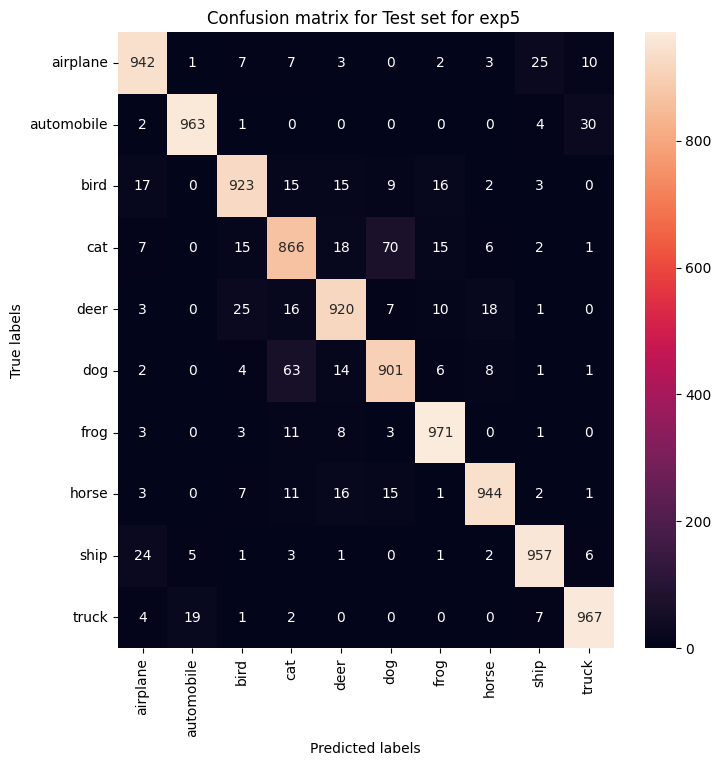

In [13]:
confusion_matrix_plot(final_matrix=history["conf_matrix"],classes_name_list=cifar10_classes,experiment_name="exp5")

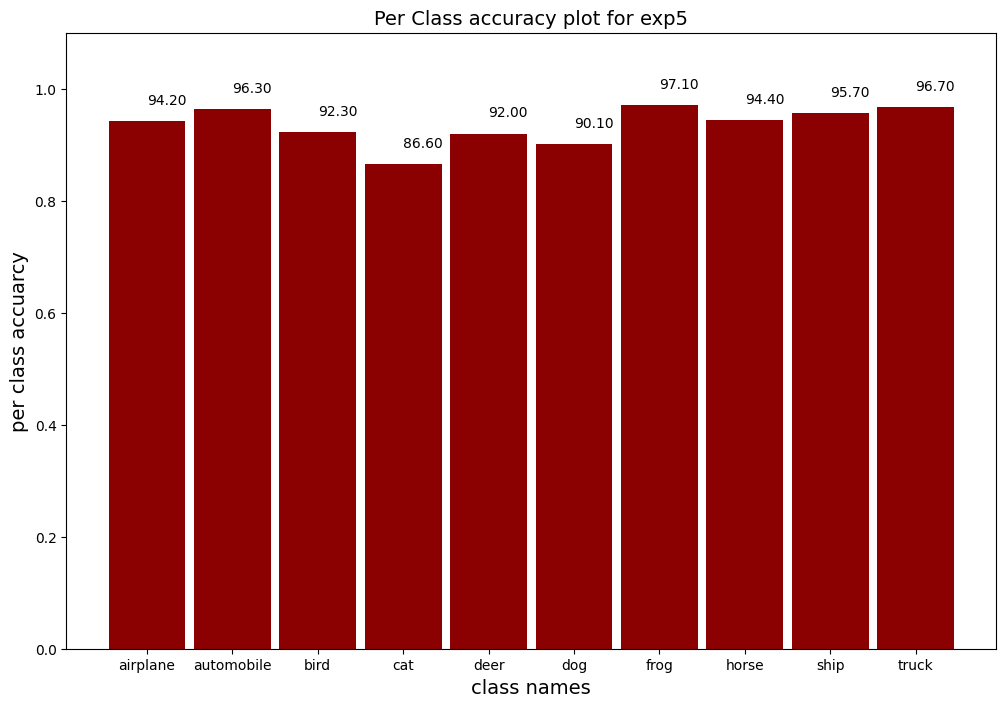

In [16]:
each_class_accuracy(final_matrix=get_test_history_dict(dict_path="./result",experiment_name="exp5")["conf_matrix"],classes_name_list=cifar10_classes,experiment_name="exp5")

## test experiment 3 model ------ (layers=[layer4,fc],learning  rates=[1e-4,1e-3]) + just standard augmentation

In [ ]:
model=load_model_for_test(
    is_baseline=False,
    model_dir=csv_file_path,
    experiment_name="exp3",
    num_classes=10,
    device=device
    )

history=test_model(
    model=model,
    test_dataloader=test_loader,
    num_classes=10,
    device=device,
    test_result_dir="./result/exp3"
        )

change the head of resnet18 to 10
--- Extracting Configurations ---
Extracted learning rates from training: [0.0001, 0.001]


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.6, which is newer than your current Lightning version: v2.6.5
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


test model is in progress:   0%|          | 0/79 [00:00<?, ?it/s]

In [ ]:
print(history)

{'test_acc': 89.42999839782715, 'test_loss': 0.3059269127589238}


## Experiment 2 ---- (layers=[layer4,fc],learning rates=[1e-4,1e-3]) Note: just unfreezing layer4 and fc

In [ ]:
model=load_model_for_test(
    is_baseline=False,
    model_dir=csv_file_path,
    experiment_name="exp2",
    num_classes=10,
    device=device
    )

history=test_model(
    model=model,
    test_dataloader=test_loader,
    num_classes=10,
    device=device,
    test_result_dir="./result/exp2"
        )
print (history)

change the head of resnet18 to 10
--- Extracting Configurations ---
Extracted learning rates from training: [0.0001, 0.001]


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.6, which is newer than your current Lightning version: v2.6.5
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


test model is in progress:   0%|          | 0/79 [00:00<?, ?it/s]

{'test_acc': 87.45999932289124, 'test_loss': 0.3679772609774071}


## Baseline test result --- (layers=[fc], learning rates=[1e-3])

In [26]:
model=load_model_for_test(
    is_baseline=True,
    model_dir=csv_file_path,
    experiment_name="baseline",
    num_classes=10,
    device=device
    )

history=test_model(
    model=model,
    test_dataloader=test_loader,
    num_classes=10,
    device=device,
    test_result_dir="./result/baseline"
        )

change the head of resnet18 to 10


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


test model is in progress:   0%|          | 0/79 [00:00<?, ?it/s]

In [29]:
print(history)

{'test_acc': 79.25999760627747, 'test_loss': 0.6184413768822634, 'conf_matrix': tensor([[817,  10,  41,   8,   5,   2,   6,  20,  67,  24],
        [ 22, 881,   4,   5,   0,   2,   3,   9,  14,  60],
        [ 46,   4, 739,  40,  61,  25,  45,  21,  14,   5],
        [ 21,   5,  49, 638,  35, 147,  55,  27,  12,  11],
        [ 14,   2,  58,  31, 746,  16,  33,  87,   9,   4],
        [  4,   1,  34, 108,  27, 750,  19,  52,   3,   2],
        [  6,   5,  48,  37,  39,  25, 824,   8,   5,   3],
        [ 14,   5,  26,  21,  49,  33,  13, 821,   9,   9],
        [ 79,  27,  13,   8,   1,   5,   3,   3, 843,  18],
        [ 23,  63,   2,   7,   1,   5,   2,   5,  25, 867]])}


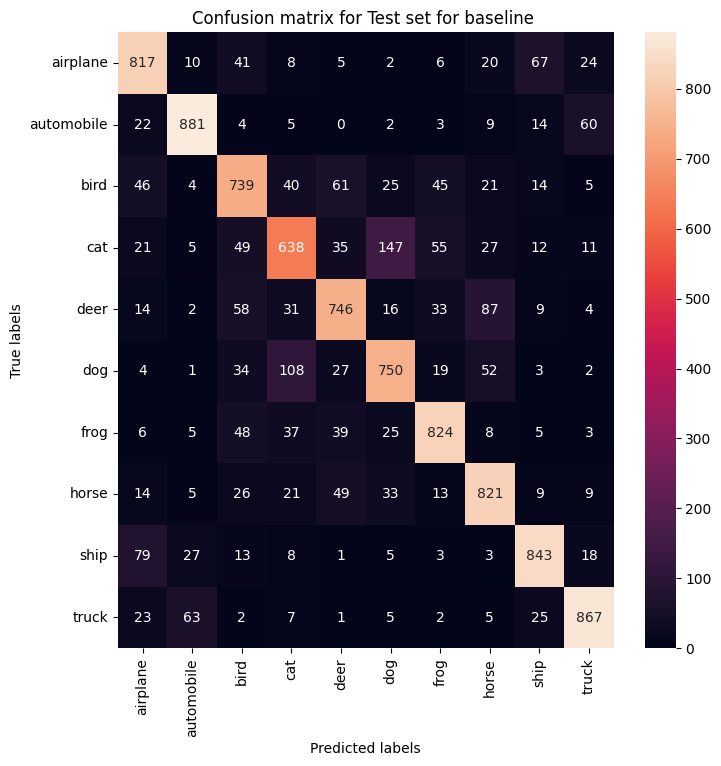

In [30]:
confusion_matrix_plot(final_matrix=history["conf_matrix"],classes_name_list=cifar10_classes,experiment_name="baseline")

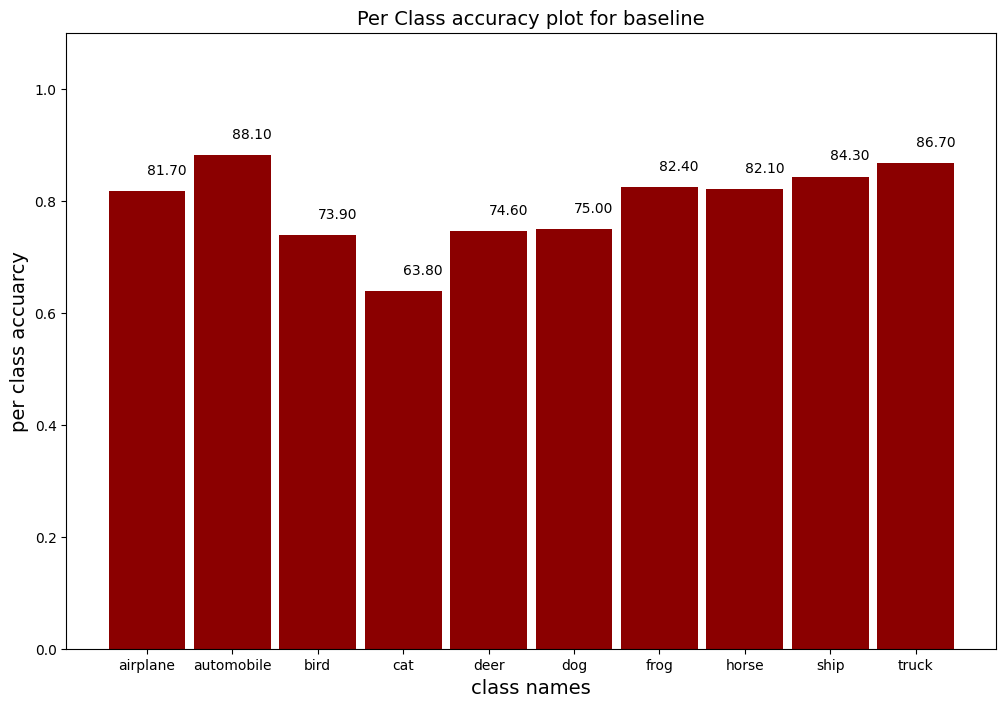

In [15]:
each_class_accuracy(final_matrix=get_test_history_dict(dict_path="./result",experiment_name="baseline")["conf_matrix"],classes_name_list=cifar10_classes,experiment_name="baseline")